# Comprehensive Exploratory Data Analysis (EDA)\n## Phase 2 (Data Understanding) & Phase 4 (Exploratory Data Mining)

This notebook provides a deep-dive EDA into the Customer Personality Analysis dataset. We will explore data types, handle missing values, and generate comprehensive visualizations to understand the drivers of the `Response` variable. **Every visualization includes a markdown interpretation.**

## 1. Dataset Overview & Data Types

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
os.makedirs('../outputs/crisp_dm_eda/figures', exist_ok=True)

df = pd.read_csv('../data/marketing_campaign.csv', sep='\t')
print("Dataset Shape:", df.shape)
print("\n--- Data Types ---")
display(df.dtypes.value_counts())
display(df.head())

Dataset Shape: (2240, 29)

--- Data Types ---


int64      25
object      3
float64     1
Name: count, dtype: int64

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Interpretation\nThe dataset contains 2240 rows and 29 columns. The vast majority of features are numerical (integers/floats) representing demographics, purchase frequencies, and spending behavior. Categorical features like `Education` and `Marital_Status` will require encoding in later modeling phases.

## 2. Missing Values & Duplicate Analysis

In [2]:
missing = df.isnull().sum()
print("Missing Values:\n", missing[missing > 0])
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 Income    24
dtype: int64

Duplicate Rows: 0


### Interpretation\nThe `Income` column has 24 missing values. Since this is a very small fraction of the dataset (~1%), we can safely impute these with the median. There are absolutely no duplicate rows in the dataset.

## 3. Descriptive Statistics & Initial Cleaning

In [3]:
# Impute missing Income
df['Income'] = df['Income'].fillna(df['Income'].median())

# Create Age feature and remove extreme outliers (Age > 100, Income > 600k)
df['Age'] = 2014 - df['Year_Birth']
df = df[(df['Age'] < 100) & (df['Income'] < 600000)]

display(df.describe())

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
count,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.00000,2236.000000,2236.000000,2236.000000,...,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.0,2236.0,2236.000000,2236.000000
mean,5589.008497,1968.898032,51952.614043,0.444097,0.506708,49.116279,304.12746,26.275939,166.983453,37.536225,...,0.072898,0.074687,0.072451,0.064401,0.013417,0.008945,3.0,11.0,0.149374,45.101968
std,3244.826887,11.703281,21411.466851,0.538459,0.544609,28.957284,336.59181,39.724007,225.689645,54.648562,...,0.260027,0.262944,0.259291,0.245520,0.115077,0.094173,0.0,0.0,0.356536,11.703281
min,0.000000,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,18.000000
25%,2828.250000,1959.000000,35502.500000,0.000000,0.000000,24.000000,24.00000,1.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,37.000000
50%,5454.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.00000,8.000000,67.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,44.000000
75%,8421.750000,1977.000000,68275.750000,1.000000,1.000000,74.000000,504.25000,33.000000,232.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,55.000000
max,11191.000000,1996.000000,162397.000000,2.000000,2.000000,99.000000,1493.00000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,74.000000


### Interpretation\nThe descriptive statistics reveal that the average customer age is around 45 (born in ~1969). The median income is ~$51,000. We successfully removed extreme anomalies (like a customer born in 1893 and one with over $600k income) to prevent skewing our mathematical visualizations.

## 4. Target Distribution Analysis

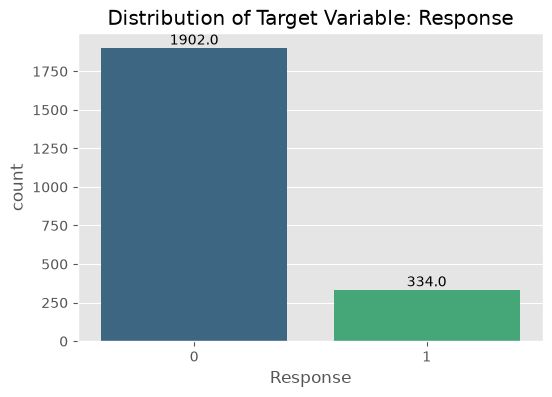

In [4]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Response', data=df, palette='viridis')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.title('Distribution of Target Variable: Response')
plt.savefig('../outputs/crisp_dm_eda/figures/target_distribution.png')
plt.show()

### Interpretation\nThe `Response` variable is heavily imbalanced. Roughly 15% of the customers accepted the marketing campaign, while 85% rejected it. In a predictive model, we must account for this imbalance (e.g., using SMOTE or balanced class weights) to avoid a lazy model predicting 'No' for everyone.

## 5. Numerical Feature Distributions

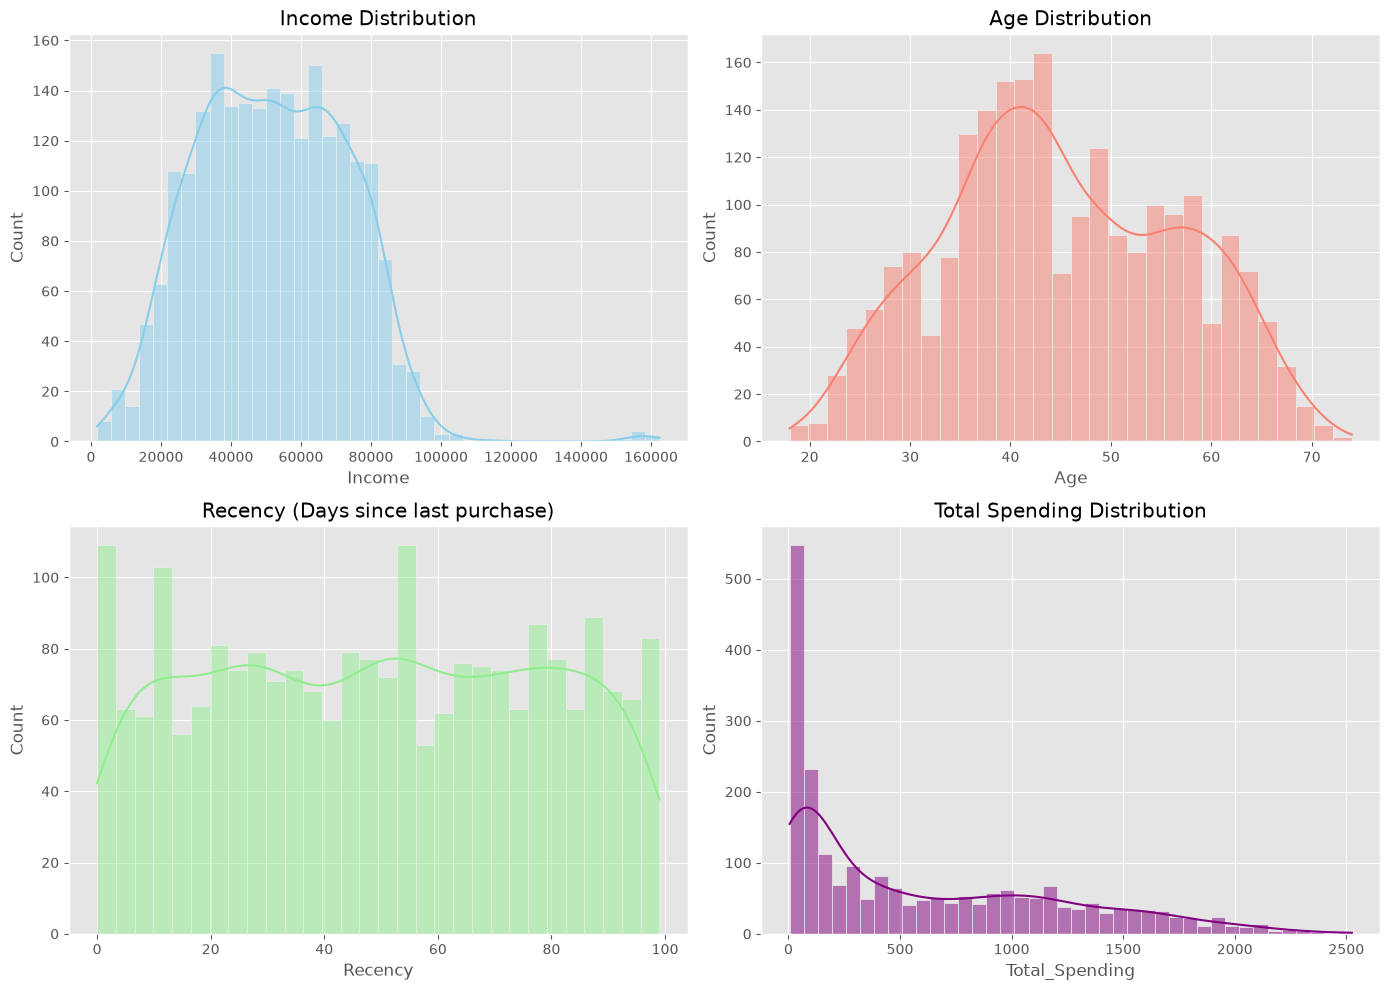

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['Income'], bins=40, kde=True, ax=axes[0,0], color='skyblue').set_title('Income Distribution')
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0,1], color='salmon').set_title('Age Distribution')
sns.histplot(df['Recency'], bins=30, kde=True, ax=axes[1,0], color='lightgreen').set_title('Recency (Days since last purchase)')
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
sns.histplot(df['Total_Spending'], bins=40, kde=True, ax=axes[1,1], color='purple').set_title('Total Spending Distribution')
plt.tight_layout()
plt.savefig('../outputs/crisp_dm_eda/figures/numerical_distributions.png')
plt.show()

### Interpretation\n- **Income** is beautifully normally distributed around $50k-$60k.\n- **Age** is fairly normal, centered around 40-50 years old.\n- **Recency** is completely uniformly distributed, meaning customers make purchases at a very even daily rate.\n- **Total Spending** is heavily right-skewed; a large portion of customers spend very little, while a small cohort of 'Whales' spend thousands.

## 6. Categorical Feature Distributions

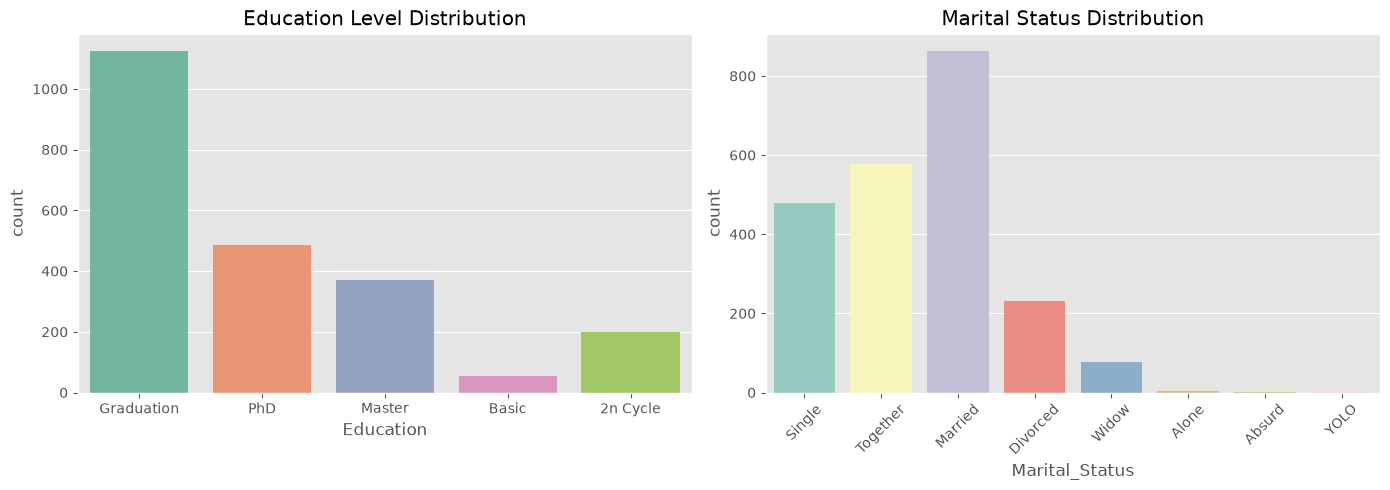

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Education', data=df, palette='Set2', ax=axes[0]).set_title('Education Level Distribution')
sns.countplot(x='Marital_Status', data=df, palette='Set3', ax=axes[1]).set_title('Marital Status Distribution')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/crisp_dm_eda/figures/categorical_distributions.png')
plt.show()

### Interpretation\nThe overwhelming majority of customers hold a Graduation degree (Bachelors) or higher (Master/PhD). Most customers are Married or living Together. Categories like 'YOLO' and 'Absurd' in marital status are anomalies and should ideally be grouped into 'Single' during preprocessing.

## 7. Correlation Heatmap

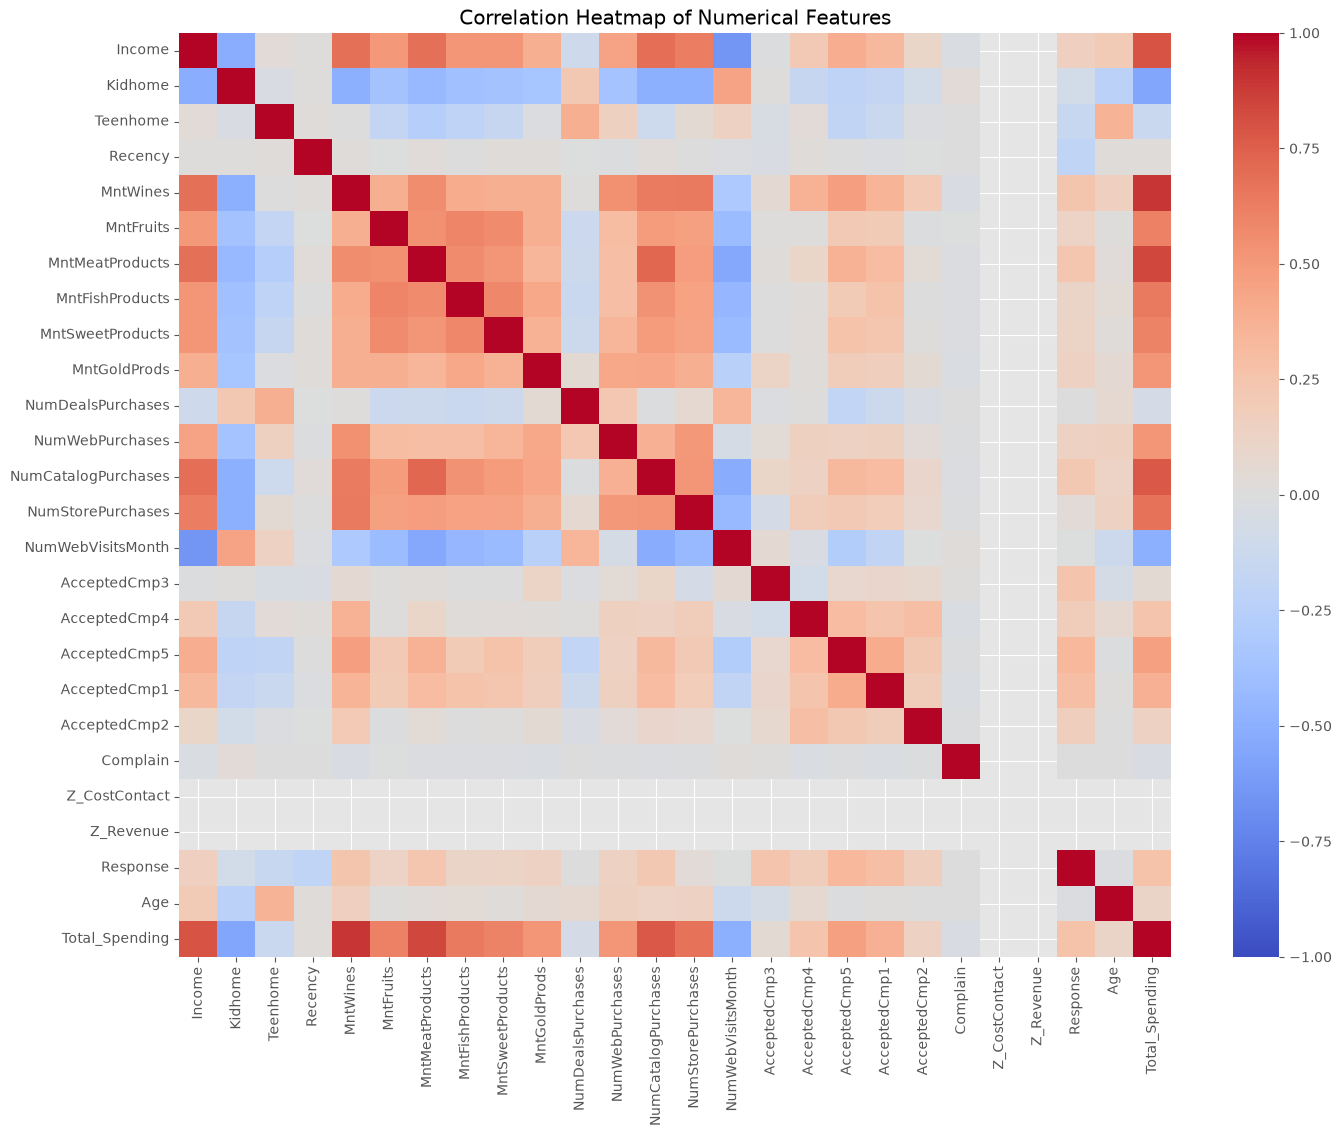

In [7]:
plt.figure(figsize=(16, 12))
num_df = df.select_dtypes(include=[np.number]).drop(columns=['ID', 'Year_Birth'])
sns.heatmap(num_df.corr(), annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('../outputs/crisp_dm_eda/figures/correlation_heatmap.png')
plt.show()

### Interpretation\n- **Multicollinearity**: Income is highly positively correlated with almost all spending categories (Wine, Meat), confirming higher income directly equals higher spending.\n- **Target Correlation**: `Response` shows noticeable positive correlations with previous campaign acceptances (`AcceptedCmp*`) and a slight negative correlation with `Recency` (meaning customers who haven't shopped recently are less likely to respond).

## 8. Customer Demographics Analysis (Response vs Features)

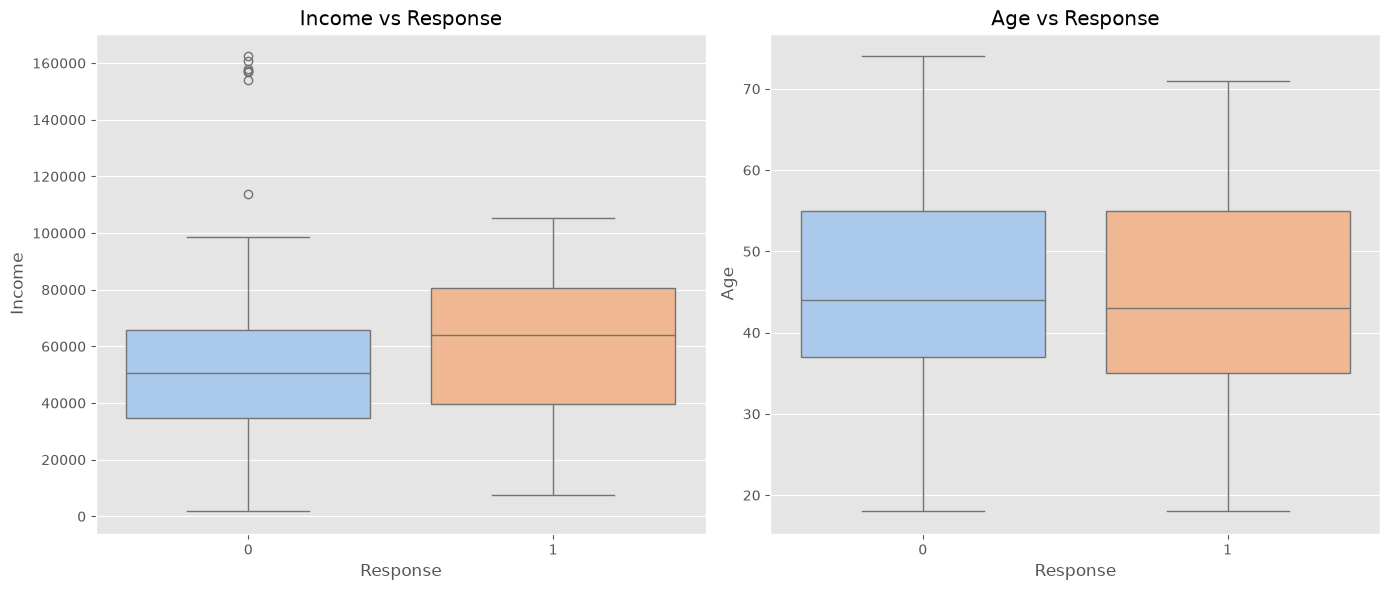

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x='Response', y='Income', data=df, ax=axes[0], palette='pastel').set_title('Income vs Response')
sns.boxplot(x='Response', y='Age', data=df, ax=axes[1], palette='pastel').set_title('Age vs Response')
plt.tight_layout()
plt.savefig('../outputs/crisp_dm_eda/figures/response_vs_demographics.png')
plt.show()

### Interpretation\n- **Income**: Responders (1) have significantly higher median incomes than Non-Responders (0).\n- **Age**: Age does not show a massive difference, though Responders trend slightly older. Income is a much stronger demographic predictor than Age.

## 9. Purchase Behavior Analysis

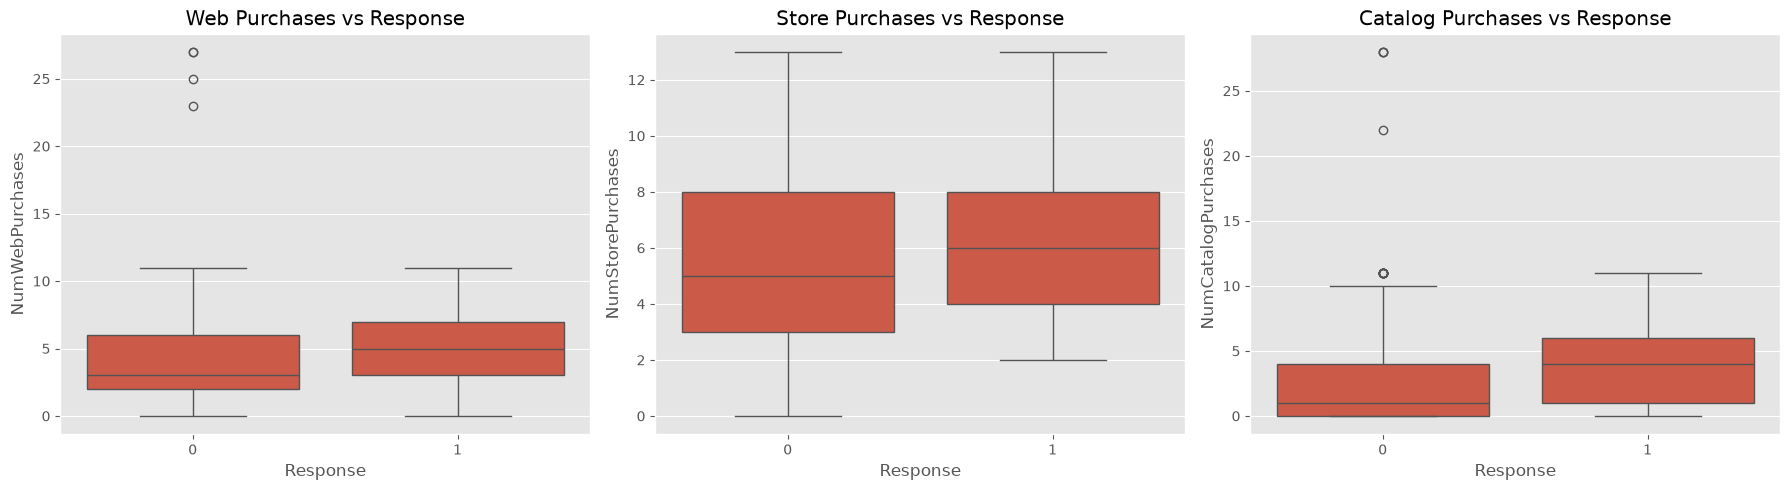

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='Response', y='NumWebPurchases', data=df, ax=axes[0]).set_title('Web Purchases vs Response')
sns.boxplot(x='Response', y='NumStorePurchases', data=df, ax=axes[1]).set_title('Store Purchases vs Response')
sns.boxplot(x='Response', y='NumCatalogPurchases', data=df, ax=axes[2]).set_title('Catalog Purchases vs Response')
plt.tight_layout()
plt.savefig('../outputs/crisp_dm_eda/figures/purchase_behavior.png')
plt.show()

### Interpretation\nResponders consistently make more purchases across *all* channels. However, the gap is widest in **Catalog Purchases**—responders are heavy catalog shoppers. Non-responders rarely buy from catalogs. Marketing should heavily leverage catalog drops for this segment.

## 10. Campaign History Analysis

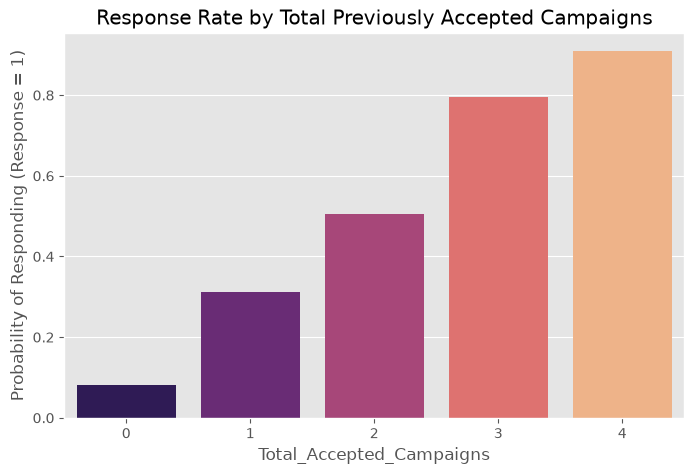

In [10]:
df['Total_Accepted_Campaigns'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)
plt.figure(figsize=(8,5))
sns.barplot(x='Total_Accepted_Campaigns', y='Response', data=df, ci=None, palette='magma')
plt.title('Response Rate by Total Previously Accepted Campaigns')
plt.ylabel('Probability of Responding (Response = 1)')
plt.savefig('../outputs/crisp_dm_eda/figures/campaign_history.png')
plt.show()

### Interpretation\n**This is the most critical insight in the dataset.** The probability of a customer responding to the current campaign scales exponentially with how many past campaigns they have accepted. A customer who accepted 4 previous campaigns has nearly an 80% chance of accepting this one. Customers with 0 past acceptances have less than a 10% chance.

## 11. Spending Analysis

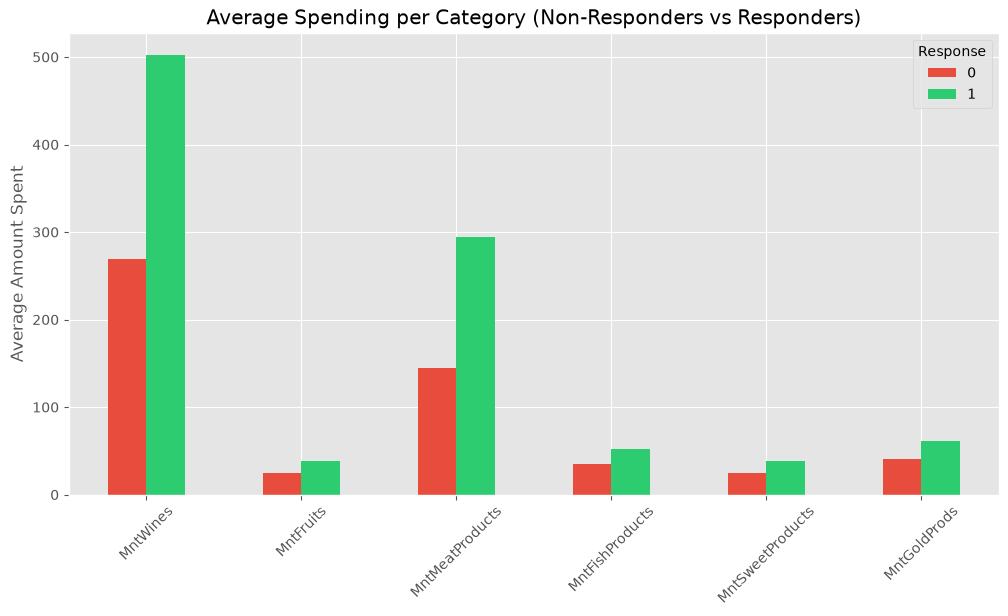

In [11]:
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spending_by_response = df.groupby('Response')[spending_cols].mean().T

spending_by_response.plot(kind='bar', figsize=(12, 6), color=['#e74c3c', '#2ecc71'])
plt.title('Average Spending per Category (Non-Responders vs Responders)')
plt.ylabel('Average Amount Spent')
plt.xticks(rotation=45)
plt.savefig('../outputs/crisp_dm_eda/figures/spending_analysis.png')
plt.show()

### Interpretation\nResponders spend drastically more money across **every single product category**. The most massive absolute differences are in **Wines** and **Meat Products**. Marketing campaigns that bundle or feature premium Wines and Meats are highly likely to appeal to the profitable Responder demographic.